# Charte graphique

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">1. Section principale</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.1 Sous-section</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.1.1 Sous-sous-section</p>

##### <p style="background-color:#b8d1e2;color:black; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.1.1.x.x.x. Toutes les autres sous-section</p>

# <p style="background: linear-gradient(90deg, #1A5276, #2980B9); color:#FFFFFF; padding:30px; border-radius:10px; text-align:center;"><span style="font-size:34px; font-weight:bold;">Comparez des algorithmes d'IA entre Machine Learning et LLM</span><br></p>

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">0. Import</p>


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import ast
import json
sns.set_theme(style="whitegrid")
PAL = ["#1A5276", "#2980B9", "#AED6F1", "#b8d1e2", "#5DADE2"]
plt.rcParams["figure.figsize"] = (10, 5)

In [42]:
from sentence_transformers import SentenceTransformer
import tiktoken
from sklearn.metrics.pairwise import cosine_similarity
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score, cross_validate, cross_val_predict,train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix

import plotly.subplots as sp
import plotly.graph_objects as go
import plotly.express as px

In [3]:
#Charger les datas
data = pd.read_csv("../data_set/dataset.csv", low_memory=False)

In [4]:
#Varibale pour créer les embeddings ATTENTION calcule trés long
RUN_EMBEDDINGS = False

In [5]:
#Token Mammouth
from dotenv import load_dotenv,  find_dotenv
import os

# load_dotenv() cherche le fichier .env à la racine du projet
# et charge ses variables dans os.environ

load_dotenv(find_dotenv())

TOKEN_MAMMOUTH = os.getenv("MAMMOUTH_TOKEN")

In [6]:
#colonne cible
TARGET = "Tag"
#Feature
FEATURES = "Consumer Claim"
#random state 
STATE = 42

In [7]:
#Réinitialisation et sauvergarde d'un dataframe df_model_score vide
def reinit_df_score():
    df_model_score = pd.DataFrame({"model": [],
                                   "id":[],
                                    "generation": [],
                                    "pipeline":[],
                                    "precision":[],
                                    "recall":[],
                                    "f1_weighted":  [],
                                    "roc_auc":[],
                                    "taille_du_set":[],
                                    "description":[]})
    df_model_score.to_pickle("../data/df_model_score.plk")

def save_score(name:str="df_model_score.plk"):
    path = "../data/" + name
    df_model_score.to_pickle(path)    

#chargement des données précédentes
df_model_score = pd.read_pickle("../data/df_model_score.plk")

(1282355, 15)

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">1. Exploration des données</p>



### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.1 Chargement et aperçu général</p>

Le jeu de données provient de la **CFPB** (Consumer Financial Protection Bureau). Il regroupe les plaintes de consommateurs dans le domaine financier. Notre objectif est de construire un **modèle de tagging automatique** : à partir du texte de la plainte (`Consumer Claim`), il faut prédire la catégorie (`Tag`).



In [368]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1282355 non-null  str  
 1   Tag                           1282355 non-null  str  
 2   Consumer Claim                383564 non-null   str  
 3   Company public response       449082 non-null   str  
 4   Company                       1282355 non-null  str  
 5   State                         1262955 non-null  str  
 6   ZIP code                      1167057 non-null  str  
 7   Tags                          175643 non-null   str  
 8   Consumer consent provided?    690654 non-null   str  
 9   Submitted via                 1282355 non-null  str  
 10  Date sent to company          1282355 non-null  str  
 11  Company response to consumer  1282348 non-null  str  
 12  Timely response?              1282355 non-null  str  
 13  Consumer

In [369]:
data.nunique()

Date received                      2717
Tag                                  18
Consumer Claim                   366945
Company public response              10
Company                            5275
State                                63
ZIP code                          22591
Tags                                  3
Consumer consent provided?            4
Submitted via                         6
Date sent to company               2666
Company response to consumer          8
Timely response?                      2
Consumer disputed?                    2
Complaint ID                    1282355
dtype: int64

In [370]:
data.dtypes.value_counts().rename_axis("Type de donnée").to_frame("Nb colonnes")

,Nb colonnes
Type de donnée,
str,14
int64,1


| type | collone| valeurs |
|:-------|:------:|-------:|
| cible  | tag    | 18 valeurs     |
|        |      |      |
| Entrée |       |       |
|        | Date received  | 2717 valeurs     |
|   | Consumer Claim       | 366945 valeurs      |
|   | Company      |5275 valeurs     |
|   | State       |63  valeurs     |
|   | ZIP code       | 22591 valeurs     |
|   | Tags     | ['Older American', nan, 'Servicemember', 'Older American, Servicemember']     |
|   | Submitted via        | ['Web', 'Referral', 'Postal mail', 'Phone', 'Fax', 'Email']     |
| Reponse|       |       |
|   | Consumer consent provided?     | [nan, 'Consent not provided', 'Other', 'Consent withdrawn', 'Consent provided']      |
|   | Date sent to company       | 2666      |
|   | Company response to consumer |['In progress','Closed with explanation','Closed with non-monetary relief','Closed with monetary relief' 'Untimely response',nan,'Closed','Closed without relief','Closed with relief']      |
|   | Timely response?      | ['Yes', 'No']     |
|   | Consumer disputed?       | [nan, 'No', 'Yes']      |


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.2 Données manquantes</p>

Le texte des plaintes (`Consumer Claim`) est la **variable d'entrée principale** pour notre tagging : il est essentiel d'analyser sa complétude.

In [371]:
missing = data.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({"Valeurs manquantes": missing, "% manquant": missing_pct})
missing_df[missing_df["Valeurs manquantes"] > 0]

,Valeurs manquantes,% manquant
Tags,1106712,86.30
Consumer Claim,898791,70.09
Company public response,833273,64.98
Consumer consent provided?,591701,46.14
Consumer disputed?,513854,40.07
ZIP code,115298,8.99
State,19400,1.51
Company response to consumer,7,0.00


C:\Users\Jerem\AppData\Local\Temp\ipykernel_20608\3265560053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=non_zero.index, y=non_zero["% manquant"], palette=PAL)
C:\Users\Jerem\AppData\Local\Temp\ipykernel_20608\3265560053.py:3: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=non_zero.index, y=non_zero["% manquant"], palette=PAL)


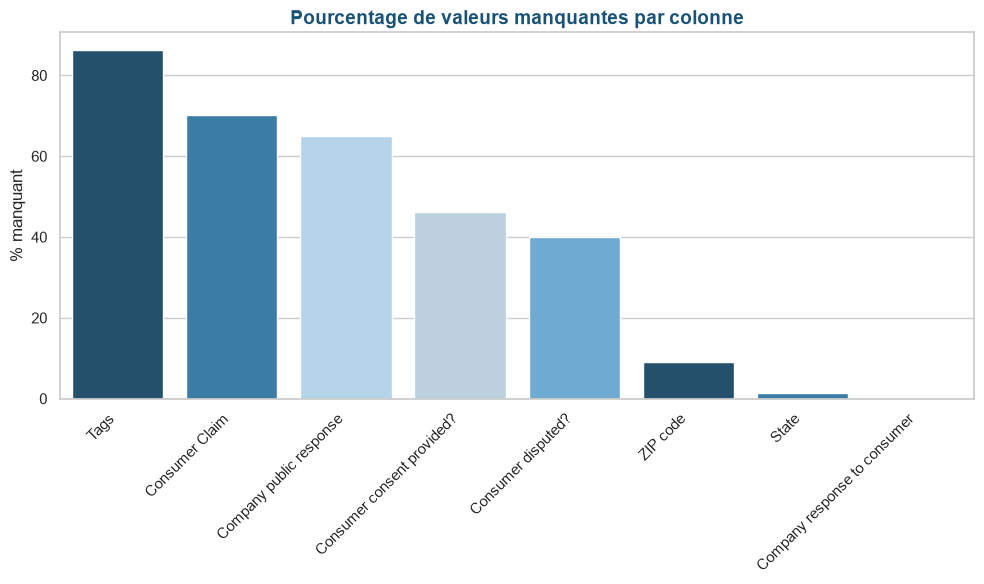

In [372]:
non_zero = missing_df[missing_df["Valeurs manquantes"] > 0]
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=non_zero.index, y=non_zero["% manquant"], palette=PAL)
ax.set_title("Pourcentage de valeurs manquantes par colonne", fontsize=14, color="#1A5276", fontweight="bold")
ax.set_ylabel("% manquant")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.3 Doublons et période temporelle</p>

In [373]:
print(f"Identifiants de plaintes uniques : {data['Complaint ID'].nunique()} / {len(data)}")
print(f"Doublons potentiels (lignes identiques) : {data.duplicated().sum()}")

data["Date received"] = pd.to_datetime(data["Date received"], format="%d/%m/%Y", errors="coerce")
data["Date sent to company"] = pd.to_datetime(data["Date sent to company"], format="%d/%m/%Y", errors="coerce")

print(f"Plage temporelle (réception) : {data['Date received'].min()} → {data['Date received'].max()}")
print(f"Nombre de jours couverts : {(data['Date received'].max() - data['Date received'].min()).days}")

Identifiants de plaintes uniques : 1282355 / 1282355
Doublons potentiels (lignes identiques) : 0
Plage temporelle (réception) : 2011-01-12 00:00:00 → 2019-12-04 00:00:00
Nombre de jours couverts : 3248


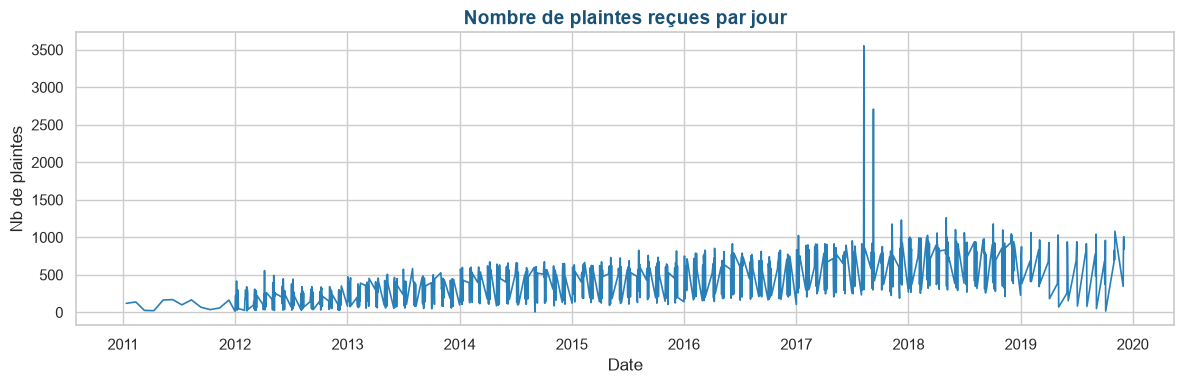

In [374]:
daily = data["Date received"].value_counts().sort_index()
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily.values, color="#2980B9", linewidth=1.2)
plt.title("Nombre de plaintes reçues par jour", fontsize=14, color="#1A5276", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Nb de plaintes")
plt.tight_layout()
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.4 Variable cible : la répartition des catégories (Tag)</p>

La variable `Tag` est notre **cible de classification**. Analysons sa distribution et son déséquilibre éventuel — un critère clé pour choisir les métriques d'évaluation des modèles.

In [375]:
tag_counts = data["Tag"].value_counts()
tag_pct = (tag_counts / len(data) * 100).round(2)
tag_dist = pd.DataFrame({"Effectif": tag_counts, "% ": tag_pct})
tag_dist

,Effectif,%
Tag,,
Mortgage,278098,21.69
Debt collection,244873,19.10
"Credit reporting, credit repair services, or other personal consumer reports",225978,17.62
Credit reporting,140432,10.95
Credit card,89190,6.96
Bank account or service,86206,6.72
Student loan,51685,4.03
Credit card or prepaid card,47653,3.72
Checking or savings account,40641,3.17


C:\Users\Jerem\AppData\Local\Temp\ipykernel_20608\1844437372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tag_dist.index, y=tag_dist["% "].values, palette=PAL)
C:\Users\Jerem\AppData\Local\Temp\ipykernel_20608\1844437372.py:2: UserWarning: 
The palette list has fewer values (5) than needed (18) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=tag_dist.index, y=tag_dist["% "].values, palette=PAL)


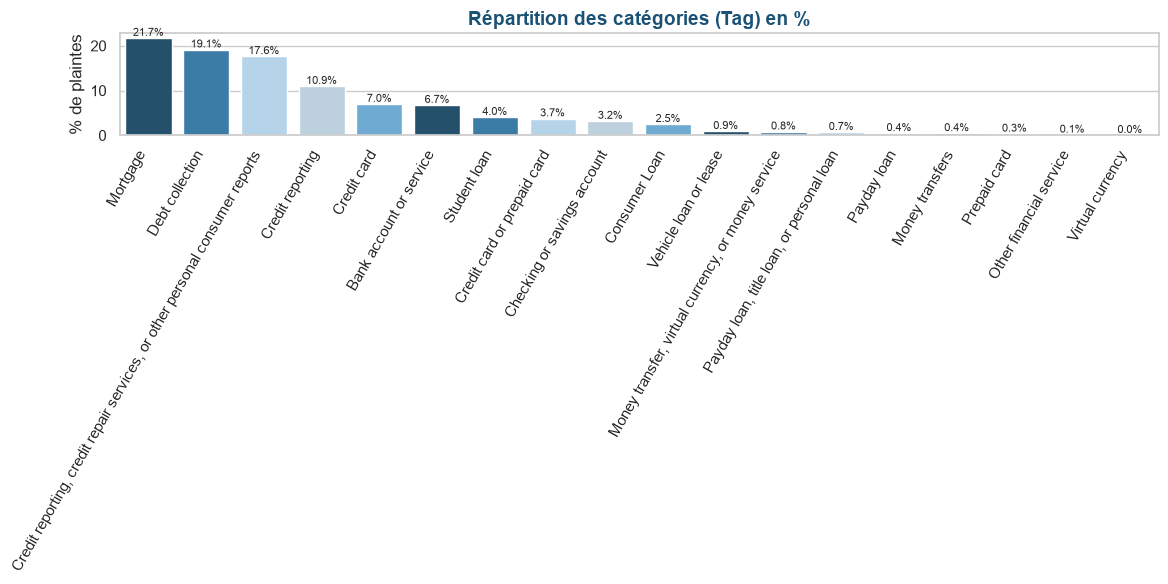

In [376]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=tag_dist.index, y=tag_dist["% "].values, palette=PAL)
ax.set_title("Répartition des catégories (Tag) en %", fontsize=14, color="#1A5276", fontweight="bold")
ax.set_ylabel("% de plaintes")
ax.set_xlabel("")
plt.xticks(rotation=60, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)
plt.tight_layout()
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.5 Analyse des autres variables catégorielles</p>

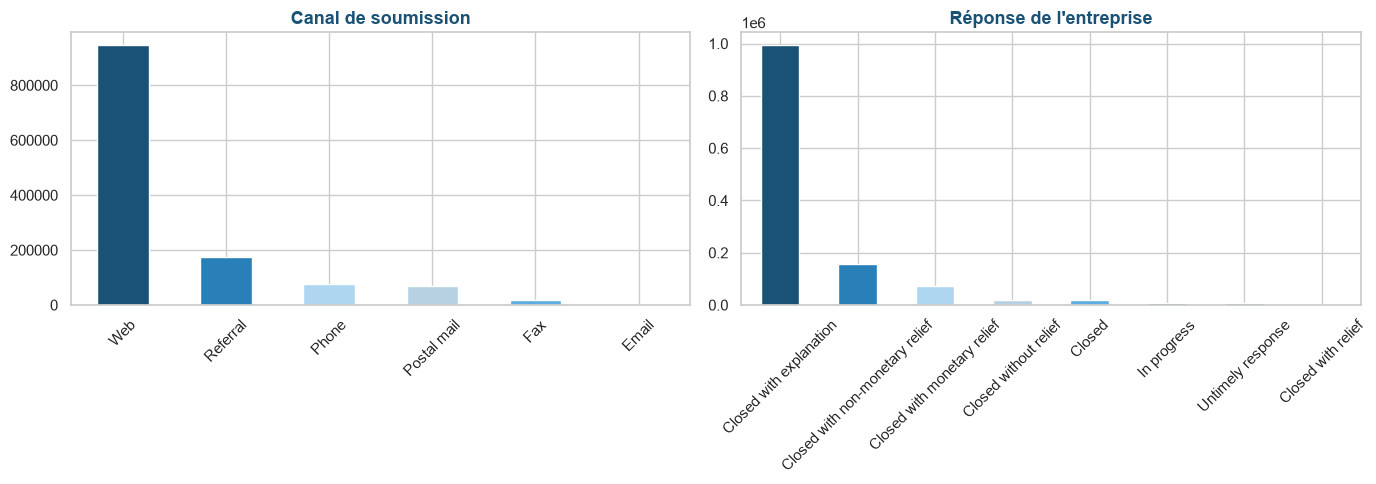

In [377]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data["Submitted via"].value_counts().plot.bar(ax=axes[0], color=PAL)
axes[0].set_title("Canal de soumission", fontsize=13, color="#1A5276", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

data["Company response to consumer"].value_counts().plot.bar(ax=axes[1], color=PAL)
axes[1].set_title("Réponse de l'entreprise", fontsize=13, color="#1A5276", fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

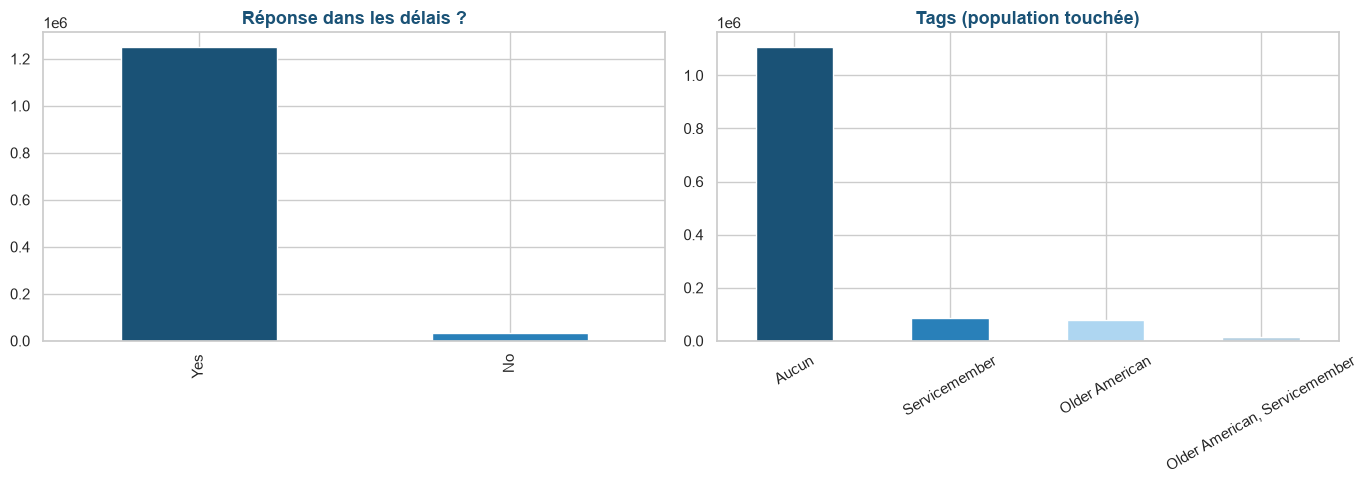

In [378]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data["Timely response?"].value_counts().plot.bar(ax=axes[0], color=PAL)
axes[0].set_title("Réponse dans les délais ?", fontsize=13, color="#1A5276", fontweight="bold")
axes[0].set_xlabel("")

data["Tags"].fillna("Aucun").value_counts().plot.bar(ax=axes[1], color=PAL)
axes[1].set_title("Tags (population touchée)", fontsize=13, color="#1A5276", fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.6 Analyse du texte des plaintes (Consumer Claim)</p>

Le champ `Consumer Claim` est la source d'information pour notre modélisation. Seule ~30% des lignes en sont renseignées : vérifions la longueur du texte et quelques exemples.

Plaintes avec texte : 383564 (29.9%)
Longueur moyenne (nb de caractères) : 1082
Longueur médiane (nb de caractères) : 744


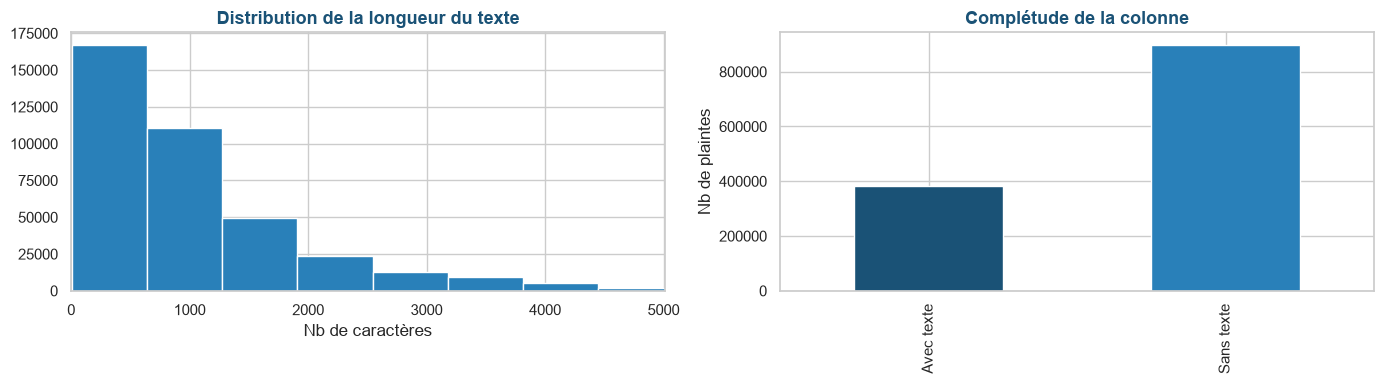


--- Exemples de plaintes ---

[1] I bought a XXXX XXXX XXXX with XXXX milies ont it from XXXX XXXX, the car currently has XXXX   miles on it and is listed in the XXXX XXXX XXXX for only XXXX, but yet I'm paying {$400.00} a month for 4 years which will total out to be around XXXX after it's all said and done. The car is in terrible c

[2] What happenedDescribe what happened so we can understand the issue ... 

Saturday XXXX XXXX, XXXX and major complaint. Previous complaints addressed harassing phone calls. You stated that no more phone calls. I was awaken at XXXX Hawaii Standard Time by a phone call from your representative. Message

[3] On XXXX 2014 my SS was stolen & used, and my Computer was acked : finally 2 years later they have taken out a lot but there are still error I am XXXX years old. my car was in the shop for repairs XXXX I need it for going to the grocery & Dr. appointment plus I had in 2014 XXXX & XXXX must see the XX


In [379]:
claim = data["Consumer Claim"].dropna().astype(str)
print(f"Plaintes avec texte : {len(claim)} ({len(claim)/len(data)*100:.1f}%)")
print(f"Longueur moyenne (nb de caractères) : {claim.str.len().mean():.0f}")
print(f"Longueur médiane (nb de caractères) : {claim.str.len().median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(claim.str.len(), bins=50, color="#2980B9", edgecolor="white")
axes[0].set_title("Distribution de la longueur du texte", fontsize=13, color="#1A5276", fontweight="bold")
axes[0].set_xlabel("Nb de caractères")
axes[0].set_xlim(0, claim.str.len().quantile(0.99))

null_share = pd.Series({"Avec texte": len(claim), "Sans texte": len(data) - len(claim)})
null_share.plot.bar(ax=axes[1], color=PAL, legend=False)
axes[1].set_title("Complétude de la colonne", fontsize=13, color="#1A5276", fontweight="bold")
axes[1].set_ylabel("Nb de plaintes")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print("\n--- Exemples de plaintes ---")
for i, txt in enumerate(claim.sample(3, random_state=42)):
    print(f"\n[{i+1}] {txt[:300]}")

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.6.1 Évolution des plaintes sans texte (Consumer Claim vide) par année</p>
Comparons, pour chaque année, le nombre de plaintes **avec** et **sans** texte, avec le pourcentage de valeurs manquantes.

In [380]:
data.columns

Index(['Date received', 'Tag', 'Consumer Claim', 'Company public response',
       'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')

In [381]:
data["annee"] = data["Date sent to company"].dt.year
res = data.groupby("annee")["Consumer Claim"].agg(total="size", rempli=lambda s: s.notna().sum()).reset_index()
res["vide"] = res["total"] - res["rempli"]
res["pct_vide"] = (res["vide"] / res["total"] * 100).round(1)
res.rename(columns={"annee": "Année", "total": "Total", "rempli": "Avec texte", "vide": "Sans texte", "pct_vide": "% vide"})

,Année,Total,Avec texte,Sans texte,% vide
0,2011.0,973,0,973,100.0
1,2012.0,26720,0,26720,100.0
2,2013.0,41075,0,41075,100.0
3,2014.0,62869,0,62869,100.0
4,2015.0,66722,20598,46124,69.1
5,2016.0,75164,30459,44705,59.5
6,2017.0,96926,45620,51306,52.9
7,2018.0,102819,47116,55703,54.2
8,2019.0,36701,8341,28360,77.3


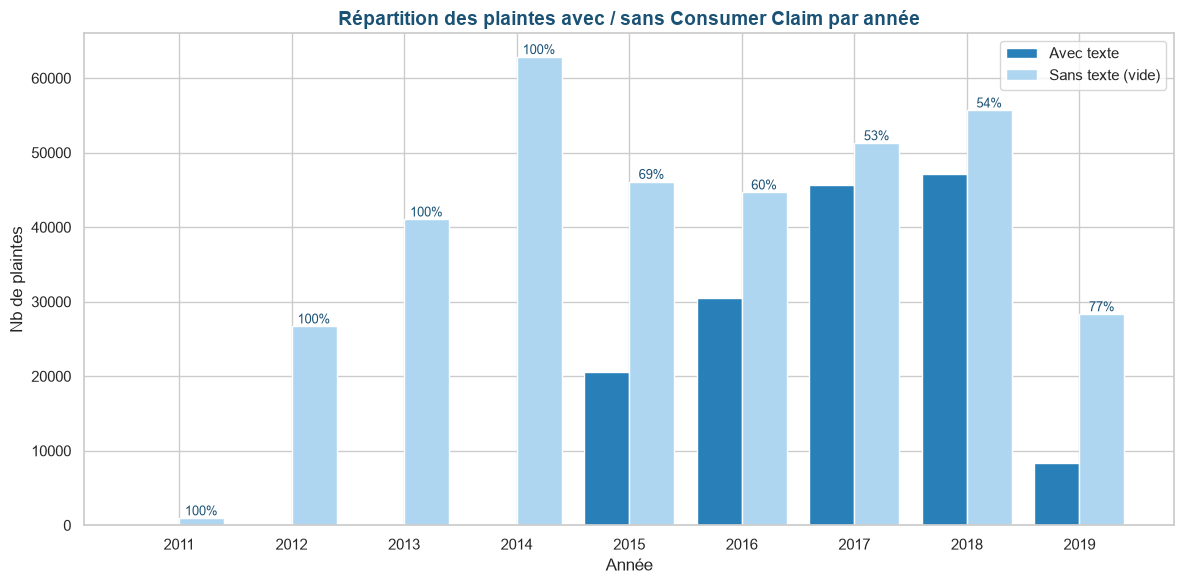

In [382]:
plt.figure(figsize=(12, 6))
bar_width = 0.4
x = np.arange(len(res))
plt.bar(x - bar_width / 2, res["rempli"], bar_width, label="Avec texte", color="#2980B9")
plt.bar(x + bar_width / 2, res["vide"], bar_width, label="Sans texte (vide)", color="#AED6F1")
plt.xticks(x, res["annee"].astype(int).astype(str))
plt.title("Répartition des plaintes avec / sans Consumer Claim par année", fontsize=14, color="#1A5276", fontweight="bold")
plt.xlabel("Année")
plt.ylabel("Nb de plaintes")
plt.legend()
for i, (v, pct) in enumerate(zip(res["vide"], res["pct_vide"])):
    plt.text(i + bar_width / 2, v, f"{pct:.0f}%", ha="center", va="bottom", fontsize=9, color="#1A5276")
plt.tight_layout()
plt.show()

In [383]:
# Est-ce que le texte manquant est réparti uniformément entre les catégories ?
df = data.copy()
df['has_narrative'] = df["Consumer Claim"].notna()

# Taux de remplissage par catégorie
fill_rate = df.groupby("Tag")['has_narrative'].mean().sort_values()
print(fill_rate)

Tag
Bank account or service                                                         0.172668
Mortgage                                                                        0.190534
Credit card                                                                     0.211212
Credit reporting                                                                0.224934
Other financial service                                                         0.275732
Money transfers                                                                 0.279604
Consumer Loan                                                                   0.299763
Payday loan                                                                     0.315115
Checking or savings account                                                     0.316946
Debt collection                                                                 0.354102
Prepaid card                                                                    0.379681
Credit reporting,

In [384]:
# Comparer effectif total et taux de remplissage pour voir si la variance 
# est corrélée à la taille de l'échantillon (ta hypothèse) ou pas
stats = df.groupby("Tag").agg(
    total_count=("Tag", 'size'),
    fill_rate=('has_narrative', 'mean')
).sort_values('total_count')

print(stats)

                                                    total_count  fill_rate
Tag                                                                       
Virtual currency                                             18   0.888889
Other financial service                                    1059   0.275732
Prepaid card                                               3819   0.379681
Money transfers                                            5354   0.279604
Payday loan                                                5544   0.315115
Payday loan, title loan, or personal loan                  8659   0.510567
Money transfer, virtual currency, or money service        10164   0.537780
Vehicle loan or lease                                     11377   0.504966
Consumer Loan                                             31605   0.299763
Checking or savings account                               40641   0.316946
Credit card or prepaid card                               47653   0.448639
Student loan             

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.7 Relation cible × canaux</p>

Vérifions si la répartition des catégories varie selon le canal de soumission (croisement utile pour comprendre le contexte).

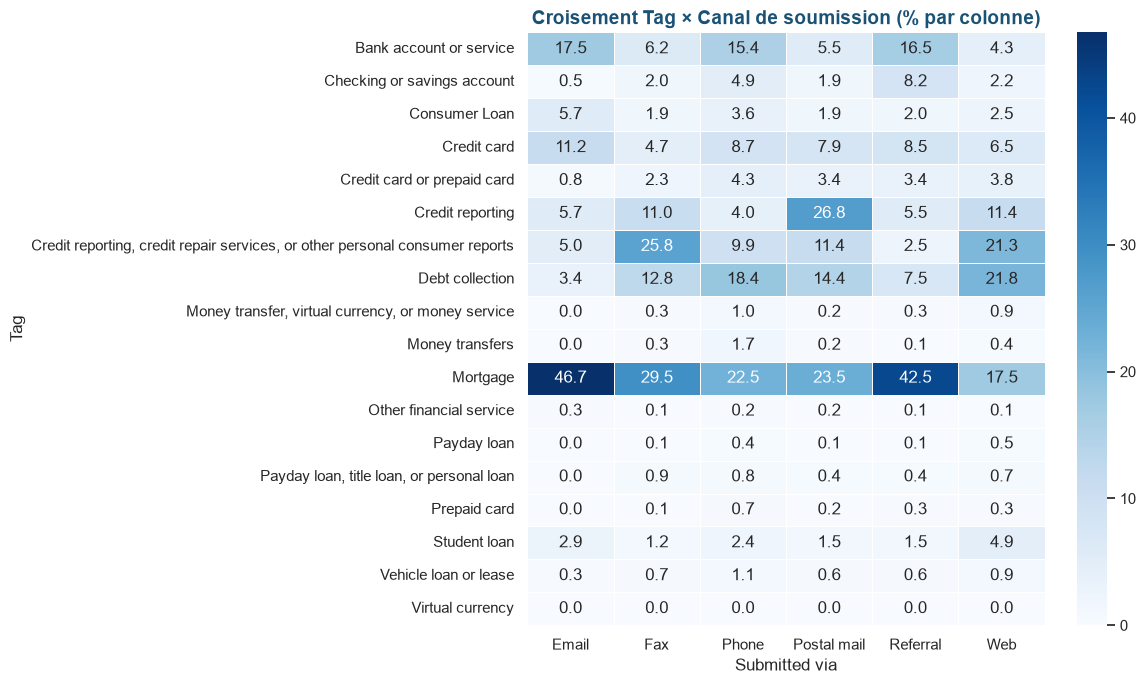

In [385]:
ct = pd.crosstab(data["Tag"], data["Submitted via"], normalize="columns") * 100
plt.figure(figsize=(12, 7))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Croisement Tag × Canal de soumission (% par colonne)", fontsize=14, color="#1A5276", fontweight="bold")
plt.tight_layout()
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.8 Recherche de potentiel cible obsolète</p>

In [386]:
df = data.groupby("annee")[TARGET].value_counts()
df

annee   Tag                                               
2011.0  Credit card                                             622
        Mortgage                                                351
2012.0  Mortgage                                              14186
        Credit card                                            5756
        Bank account or service                                4555
                                                              ...  
2019.0  Checking or savings account                            2743
        Student loan                                           1272
        Vehicle loan or lease                                   793
        Money transfer, virtual currency, or money service      642
        Payday loan, title loan, or personal loan               575
Name: count, Length: 89, dtype: int64

In [387]:
table = df.unstack(fill_value=0)
table

Tag,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,"Money transfer, virtual currency, or money service",Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
annee,,,,,,,,,,,,,,,,,,
2011.0,0,0,0,622,0,0,0,0,0,0,351,0,0,0,0,0,0,0
2012.0,4555,0,704,5756,0,570,0,0,0,0,14186,0,0,0,0,949,0,0
2013.0,5386,0,1201,5090,0,5274,0,3532,0,217,19136,0,53,0,0,1186,0,0
2014.0,6294,0,2240,5916,0,11522,0,15674,0,484,18192,38,669,0,140,1699,0,1
2015.0,6692,0,3051,6879,0,13819,0,15441,0,631,16921,127,604,0,750,1806,0,1
2016.0,8627,0,3709,8188,0,17621,0,15730,0,652,16142,167,618,0,510,3197,0,3
2017.0,2949,4715,1512,3145,5711,7029,31027,19033,1161,182,11921,71,240,1079,200,5557,1392,2
2018.0,0,8374,0,0,9414,0,44691,20539,2339,0,9788,0,0,1769,0,3542,2363,0
2019.0,0,2743,0,0,3434,0,17430,6659,642,0,3153,0,0,575,0,1272,793,0


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.9 Synthèse de l'exploration</p>

- **Volume** : ~1,28 million de plaintes, 15 colonnes.
- **Cible `Tag`** : 18 catégories **fortement déséquilibrées** (quelques catégories dominent). Il faudra gérer ce déséquilibre et choisir une métrique adaptée (macro-F1 plutôt qu'accuracy).
- **Texte `Consumer Claim`** : renseigné seulement ~30 % des lignes → nécessitera un **prétraitement** (définition d'une stratégie pour les valeurs manquantes).
- **Données manquantes** : importantes sur `Consumer Claim`, `Company public response`, `Tags`…
- **Dates** : s'étalent sur plusieurs années ; utile pour une éventuelle séparation temporelle train/test.

Ces observations guident les choix de modélisation (ML classique sur texte vs LLM) dans les sections suivantes.

On voit que les labels on changé au cours de l'année 2017
| Labels à fusionner | Label final à conserver |
|---|---|
| `Credit reporting` + `Credit reporting, credit repair services, or other personal consumer reports` | `Credit reporting, credit repair services, or other personal consumer reports` |
| `Bank account or service` + `Checking or savings account` | `Checking or savings account` |
| `Credit card` + `Credit card or prepaid card` + `Prepaid card` | `Credit card or prepaid card` |
| `Consumer Loan` + `Vehicle loan or lease` | `Vehicle loan or lease`  |
| `Payday loan` +`Consumer Loan`+ `Payday loan, title loan, or personal loan` | `Payday loan, title loan, or personal loan` |
| `Money transfers` + `Virtual currency` + `Money transfer, virtual currency, or money service` | `Money transfer, virtual currency, or money service` |



## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">2. Création du data set train test</p>


In [8]:
true_target = {
    "Mortgage":'Mortgage',
"Debt collection":'Debt collection',
"Credit reporting, credit repair services, or other personal consumer reports":"Credit reporting, credit repair services, or other personal consumer reports",
"Credit reporting":"Credit reporting, credit repair services, or other personal consumer reports",	
"Credit card":'Credit card or prepaid card',
"Bank account or service":"Bank account or service",
"Student loan":'Student loan',
"Credit card or prepaid card":'Credit card or prepaid card',	
"Checking or savings account":'Checking or savings account',
"Consumer Loan":'Payday loan, title loan, or personal loan',
"Vehicle loan or lease":'Vehicle loan or lease',
"Money transfer, virtual currency, or money service":'Money transfer, virtual currency, or money service',
"Payday loan, title loan, or personal loan":'Payday loan, title loan, or personal loan',
"Payday loan":'Payday loan, title loan, or personal loan',
"Money transfers":'Money transfer, virtual currency, or money service',
"Prepaid card":'Credit card or prepaid card',
"Other financial service":'Other financial service',
"Virtual currency":'Money transfer, virtual currency, or money service'
}


In [9]:
#colonne cible
TARGET_TEST= "target"
#Feature
FEATURES = "Consumer Claim"
#random state 
STATE = 42
#Proportion du set d'entrainement
SET_TRAIN = 1200

In [10]:
#extraction des données avec Consumer Claim remplit
df_claim = data[~data[FEATURES].isna()]

In [11]:
#Uniformisation des cibles avec les vrai nom utilisé aprés 2017
df_claim[TARGET_TEST] = df_claim["Tag"].map(true_target)
df_claim.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,target
29904,03/23/2019,"Credit reporting, credit repair services, or o...",The Summer of XX/XX/2018 I was denied a mortga...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,NaN,NaN,Consent provided,Web,03/23/2019,Closed with explanation,Yes,NaN,3189109,"Credit reporting, credit repair services, or o..."
30629,03/22/2019,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",VA,220XX,NaN,Consent provided,Web,03/22/2019,Closed with explanation,Yes,NaN,3187982,"Credit reporting, credit repair services, or o..."
30735,03/22/2019,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,770XX,NaN,Consent provided,Web,03/22/2019,Closed with explanation,Yes,NaN,3187954,"Credit reporting, credit repair services, or o..."
30795,03/22/2019,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,787XX,NaN,Consent provided,Web,03/22/2019,Closed with explanation,Yes,NaN,3188091,"Credit reporting, credit repair services, or o..."
30807,03/22/2019,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,951XX,NaN,Consent provided,Web,03/22/2019,Closed with explanation,Yes,NaN,3188119,"Credit reporting, credit repair services, or o..."


In [12]:
df = df_claim[[TARGET_TEST, FEATURES]]
df.groupby(TARGET_TEST).count()

,Consumer Claim
target,
Bank account or service,14885
Checking or savings account,12881
Credit card or prepaid card,41667
"Credit reporting, credit repair services, or other personal consumer reports",123966
Debt collection,86710
"Money transfer, virtual currency, or money service",6979
Mortgage,52987
Other financial service,292
"Payday loan, title loan, or personal loan",15642


On retire "Other financial service" car la classe est trop petite pour êtres diviser équitablement et est trop anédcotique pour être correctement apprise

In [26]:
df = df_claim[df_claim[TARGET_TEST]!="Other financial service"] 
X = df[FEATURES]
y = df[TARGET_TEST] 

# Sous-échantillonnage stratifié AVANT le split train/test
# Important : on garde les proportions de classes, sinon le modèle "jouet" 
# ne sera pas représentatif de la vraie difficulté du problème
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size= SET_TRAIN,  #nombre fix ou une fraction : train_size=30 000 ou 0.1
    random_state=STATE,
    stratify=y
)
X_sample = X
y_sample = y

# Puis split train/test habituel sur l'échantillon
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=STATE, stratify=y_sample
)

In [33]:
#Sauvegarde des data set train test au forùat .csv
d_train = {"feature":X_train, "target":y_train}
df_train = pd.DataFrame(data=d_train)
df_train.to_csv("../data/dataSet_train.csv.gz", sep=";", index=False, quoting=csv.QUOTE_NONNUMERIC)

d_test = {"feature":X_test, "target":y_test}
df_test = pd.DataFrame(data=d_test)
df_test.to_csv("../data/dataSet_test.csv.gz", sep=";", index=False, quoting=csv.QUOTE_NONNUMERIC)

In [36]:
df = pd.read_csv("../data/dataSet_train.csv.gz", sep=";")
df.head()

,feature,target
0,All of the medical on my credit report should ...,"Credit reporting, credit repair services, or o..."
1,CREDIT BUREAUS WEB SITE NOT COMPLYING TO ACQUI...,"Credit reporting, credit repair services, or o..."
2,I earned around XXXX travel rewards points by ...,Credit card or prepaid card
3,Upon calling what I though was my existing mor...,Mortgage
4,Never applied for credit Never authorized ANYO...,"Credit reporting, credit repair services, or o..."


## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">3. Test LLM</p>


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.0 Initialisation</p>

In [ ]:
#Changer cette valeur si on veux moins d'apelle api que le set d'entrainement
LEN_TEST = len(X_train)

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.1 Recherche des données à prompter par embedding</p>

In [ ]:
# modèle pré-entraîné qui transforme un texte en vecteur de sens (384 dimensions)
if(RUN_EMBEDDINGS):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(X_train.tolist())
    # Sauvegarde de l'embeddings
    np.save("../data_set/embeddings_train.npy", embeddings)
    np.save("../data_set/index_train.npy", X_train.index.to_numpy())
else: #vérifie la cohérence des données sauvegardées
    embeddings = np.load("../data_set/embeddings_train.npy")
    saved_index = np.load("../data_set/index_train.npy")

    assert (X_train.index.to_numpy() == saved_index).all(), "Désalignement détecté !"

In [ ]:
#calculer le centroïde (la moyenne vectorielle) de chaque classe

centroids = {}
for tag in y_train.unique():
    mask = (y_train == tag)
    centroids[tag] = np.mean(embeddings[mask], axis=0)

In [ ]:
#pour chaque classe, choisir le texte le plus proche de son centroïde (similarité cosinus)

def get_prototype(
    tag: str,
    X_train: pd.Series,
    y_train: pd.Series,
    embeddings: np.ndarray,
    centroids: dict[str, np.ndarray],
    k:int=3,
    max_len:int=1500,
) -> str:
    # ne garder que les indices de cette classe
    mask = (y_train == tag).values    
    lengths = X_train.str.len()
    reasonable_mask = ((lengths>100) & (lengths < max_len)).values
    final_mask = mask & reasonable_mask
    class_texts = X_train[final_mask]
    class_embeddings = embeddings[final_mask]

    # similarité entre chaque texte et le centroïde de sa classe
    sims = cosine_similarity(class_embeddings, centroids[tag].reshape(1, -1)).flatten()

    #Retourne les k plus proche = le plus "prototypique"
    top_k_idx = np.argsort(sims, descending=True)[:k]
   
    return class_texts.iloc[top_k_idx]

In [ ]:
#Recupére dans un dict toutes les phrase les plus proche pour tous les tag
prompt_text = {}
for tag in y_train.unique():
    best_text = get_prototype(tag, X_train, y_train,embeddings, centroids, k=3 )
    prompt_text[tag] = best_text


In [ ]:
#Ettiquette et exemple à donner au model
output = ""
for tag, text in prompt_text.items():
    output += f"{tag}   : \n"
    for t in text:
        output += f"    -{t}\n"
print(output)

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.2 Tester le model</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">3.2.1 Charger les prompts</p>

In [ ]:
# Lire les fichiers prompt
with open("../data/syteme_prompt.txt", "r", encoding="utf-8") as f:
    prompt_fully = f.read()
with open("../data/syteme_prompt_small.txt", "r", encoding="utf-8") as f:
    prompt_small = f.read()
with open("../data/syteme_prompt_english.txt", "r", encoding="utf-8") as f:
    prompt_english = f.read()


In [311]:
#Calcul le nombre de token du prompt
def prompt_token_size(prompt:str)->int:
    encoding = tiktoken.encoding_for_model("gpt-4o-mini")
    size = len(encoding.encode(prompt))
    print("Nombres de token estimé : ", size)
    return size

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">3.2.2 Apelle du model</p>

In [ ]:
#List model
llm_list_model = {
    1:"claude-haiku-4-5",
    2:"gpt-6-luna",
    3:"mammouth-recommended"
}
llm_model_name = llm_list_model[3]

In [ ]:
from typing import TypedDict

class Message(TypedDict):
    role: str
    content: str

class Choice(TypedDict):
    index: int
    message: Message
    finish_reason: str

class Usage(TypedDict):
    prompt_tokens: int
    completion_tokens: int
    total_tokens: int

class ApiResponse(TypedDict):
    id: str
    object: str
    created: int
    model: str
    choices: list[Choice]
    usage: Usage

def call_mamouth(sys_prompt:str, user_prompt:list[str])->ApiResponse:    

    claim = {}
    for idx, v in enumerate(user_prompt):
        claim[idx] = v
            
        
    url = "https://api.mammouth.ai/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {TOKEN_MAMMOUTH}",
        "Content-Type": "application/json"
    }
    data = {
        "model": llm_model_name,
        "messages": [
            {
                "role": "system",
                "content": sys_prompt
            },
            {
                "role": "user",
                "content":  json.dumps(claim)
                    }
        ],
        "temperature":0,
        "top_p":0
    }
    
    response = requests.post(url, headers=headers, json=data)
    return response.json()

In [448]:
#Transforme la réponse du model en une list de réponses
def verif_res(res: ApiResponse) -> list[str]:
    format_res = res["choices"][0]["message"]["content"]
    res_value: list[str] = ast.literal_eval(format_res)    
    return list(res_value["response"].values())

In [450]:
#list de toutes les réponses
MAX_CLAIM_MODEL = 100
pred_llm = []
response_list = []
for i in range(0, LEN_TEST,MAX_CLAIM_MODEL): 

    loop = 0
    succes = False

    while succes == False:
        loop += 1
        pos = min(i+MAX_CLAIM_MODEL, LEN_TEST)
        #list des claim à envoyer par paquet de 50
        list_claim = X_train[i:pos].to_list()
        len_claim = len(list_claim)
        
        #Appelle du modél
        response = call_mamouth(prompt_english,list_claim )
        #On transforme la réponse en list
        res_array = verif_res(response)
        #si le nombre de réponse corréspond on passe à la suite
        len_received = len(res_array)

        if(len_received == len_claim):
            #on ajoute les prédictions à la liste des prédiction 
            pred_llm.extend(res_array)
            #on ajoute les reponses à la liste
            response_list.append({"response":response, "claims":list_claim})
            print(f"Récupération des prédictions de {i} à {pos-1} !") 
            succes = True
            break
        else:
            print(f"Nombre de réponse incorrecte reçu : {len_received} / {len_claim}")
        
        #sinon on recommence juste une fois
        if(loop==2):
            raise ValueError(f"Le nombre de prédictions reçu est incorrect\n{response}")
     
print(f"{len(pred_llm)} prédiction récupérées")

Récupération des prédictions de 0 à 99 !
100 prédiction récupérées


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.3 Resultat du model</p>

In [ ]:
#Sauvegarde du résultat et des métriques
y_train_set = y_train[:LEN_TEST].to_list()
#Metrique
id = 1 + (int(df_model_score["id"].max()) if not df_model_score.empty else 0)
llm_score = pd.DataFrame({"model":[f"llm"],"id":[id], "generation":[f"{llm_model_name}_{id}"]})
llm_score["precision"] = precision_score(y_train_set, pred_llm, average="weighted", zero_division=0)
llm_score["f1_weighted"] = f1_score(y_train_set, pred_llm, average='weighted', zero_division=0)
llm_score["recall"] = recall_score(y_train_set, pred_llm, average="weighted", zero_division=0)
llm_score["taille_du_set"]=[len(pred_llm)]
llm_score["description"]=llm_model_name
df_model_score = pd.concat([df_model_score, llm_score], ignore_index=True)
save_score()

In [454]:
y_train_set = y_train[:LEN_TEST].to_list()
d = {"y_test":y_train_set, "pred":pred_llm}
df = pd.DataFrame(data=d)
df["result"] = df["y_test"] == df["pred"]
df["result"].sum()

np.int64(84)

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">4. Test ML</p>



### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.0 Fonction d'entrainement et initialisation</p>

In [359]:
#Définition du schéma de validation croisée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=STATE)

scoring = {     
"precision": make_scorer(precision_score, average="weighted", zero_division=0),
"recall": make_scorer(recall_score, average="weighted", zero_division=0),
"f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
"roc_auc": "roc_auc_ovr_weighted",
}

In [360]:
def train_model(models, generation,  X_train, y_train, desc="")->pd.DataFrame:
    df = pd.DataFrame()       

    for name, model in models.items():        
        
        cv_result = cross_validate(
            model,         
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
        )

        metrics_dict = {}
        for score in scoring:
            cv_score = "test_"+score
            test = round(cv_result[cv_score].mean(),4)
            metrics_dict[score] = [test]           
        id = 1 + (int(df_model_score["id"].max()) if not df_model_score.empty else 0)
        new_score = pd.DataFrame({"model": [name],"id":[id], "generation":[f"{generation}_{id}"],"pipeline":[model], **metrics_dict, "taille_du_set":[X_train.shape], "description":[desc]})
        df = pd.concat([df, new_score], ignore_index=True)    

    return df

In [45]:
#Encodage des labels cibles
lab_enc = LabelEncoder()
y_train_encod = lab_enc.fit_transform(y_train)
y_test_encod = lab_enc.transform(y_test)


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.2 Définition des modeles</p>

In [362]:
models = {
    "logistic_regression": LogisticRegression(random_state=STATE, max_iter=1000, class_weight='balanced'),
    "random_forest": RandomForestClassifier(random_state=STATE, n_estimators=200, class_weight='balanced', max_depth=5),
    "xgboost": XGBClassifier(random_state=STATE, n_estimators=200,max_depth=5, device="cuda", tree_method="hist"),
    "Dummy Classifier": DummyClassifier(strategy="most_frequent", random_state=STATE)
}


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.2 Vecctorisation Texte, RF, LogReg, XGBoost</p>

In [ ]:
# vectorisation du texte en features numériques
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [364]:
#Entrainement
new_score = train_model(models, "vectorisation", X_train_tfidf, y_train_encod)
df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)
save_score()

d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:50:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:50:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:50:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.1 Embedding, RF, LogReg, XGBoost</p>

In [ ]:
model_embedding = SentenceTransformer('all-MiniLM-L6-v2',device="cuda")
X_train_emb = model_embedding.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model_embedding.encode(X_test.tolist(), show_progress_bar=True)

Batches: 100%|██████████| 8/8 [00:00<00:00, 19.11it/s]


In [366]:
new_score = train_model(models, "embedding", X_train_emb, y_train_encod)
df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)
save_score()

d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:51:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:51:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 12\Mission_ZenAssist\Mission_1\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:51:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\Documents

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">5. Comparaison Pérformance</p>



### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">5.1 Graphique de comparaison des métriques</p>

In [367]:
nbr_cols = 2
# Create a 3x2 grid of subplots
fig = sp.make_subplots(
    rows=-(-len(scoring) //2), cols=nbr_cols,
    subplot_titles=list(scoring.keys()),
    shared_xaxes=True
)

# Get consistent colors per model using plotly's qualitative palette
models = df_model_score["model"].unique()
colors = px.colors.qualitative.Plotly
color_map = {model: colors[i % len(colors)] for i, model in enumerate(models)}

# Loop over each metric, placing it in the right subplot position
for idx, metric in enumerate(scoring):
    row = idx // nbr_cols + 1  # subplot row (1-indexed)
    col = idx % nbr_cols+ 1    # subplot col (1-indexed)

    for model_name in models:
        group_df_model_score = df_model_score[df_model_score["model"] == model_name].sort_values("generation")

        fig.add_trace(
            go.Scatter(
                x=group_df_model_score["generation"],
                y=group_df_model_score[metric],
                mode="lines+markers",
                name=model_name,
                legendgroup=model_name,
                # Show legend only once per model (on first subplot) to avoid duplicates
                showlegend=(idx == 0),
                line=dict(color=color_map[model_name])
            ),
            row=row, col=col
        )

fig.update_xaxes(title_text="Generation")
fig.update_layout(
    height=900, width=1000,
    title_text="Évolution des métriques par génération et par modèle"
)
fig.update_xaxes(showticklabels=True)

fig.show()


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.2 Entrainement et resultat du model retenu</p>

In [ ]:
#Choix du modél retenu
model_type = "logistic_regression"
model_generation = "embedding"

#Récupération des paramétre du modéle retenu
model = df_model_score.loc[((df_model_score["model"]==model_type)&(df_model_score["generation"]==model_generation)), "pipeline"][0]
#Entrainement
model.fit(X_train_emb, y_train_encod)
#Prédiction
pred = model.predict(X_test_tfidf)

In [ ]:
y_test_decod = lab_enc.inverse_transform(y_test_encod)
pred_decod = lab_enc.inverse_transform(pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_decod, pred_decod, normalize='true', ax=ax)

# rotation des labels de l'axe x (predicted label)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
df_model_score

,model,id,generation,pipeline,precision,recall,f1_weighted,roc_auc,taille_du_set,description
0,llm,1.0,mammouth-recommended_1,NaN,0.816893,0.804688,0.801746,NaN,"(960,)",mammouth-recommended
1,logistic_regression,2.0,vectorisation_2,"LogisticRegression(class_weight='balanced', ma...",0.716000,0.725000,0.713600,0.9276,"(640, 5000)",
2,random_forest,2.0,vectorisation_2,RandomForestClassifier(class_weight='balanced'...,0.706200,0.675000,0.679800,0.8952,"(640, 5000)",
3,xgboost,2.0,vectorisation_2,"XGBClassifier(base_score=None, booster=None, c...",0.637000,0.660900,0.640500,0.9097,"(640, 5000)",
4,Dummy Classifier,2.0,vectorisation_2,"DummyClassifier(random_state=42, strategy='mos...",0.118200,0.343800,0.175900,0.5000,"(640, 5000)",
5,logistic_regression,3.0,embedding_3,"LogisticRegression(class_weight='balanced', ma...",0.733900,0.706200,0.715100,0.9296,"(640, 384)",
6,random_forest,3.0,embedding_3,RandomForestClassifier(class_weight='balanced'...,0.664700,0.671900,0.661500,0.8991,"(640, 384)",
7,xgboost,3.0,embedding_3,"XGBClassifier(base_score=None, booster=None, c...",0.650400,0.673400,0.649700,0.9100,"(640, 384)",
8,Dummy Classifier,3.0,embedding_3,"DummyClassifier(random_state=42, strategy='mos...",0.118200,0.343800,0.175900,0.5000,"(640, 384)",


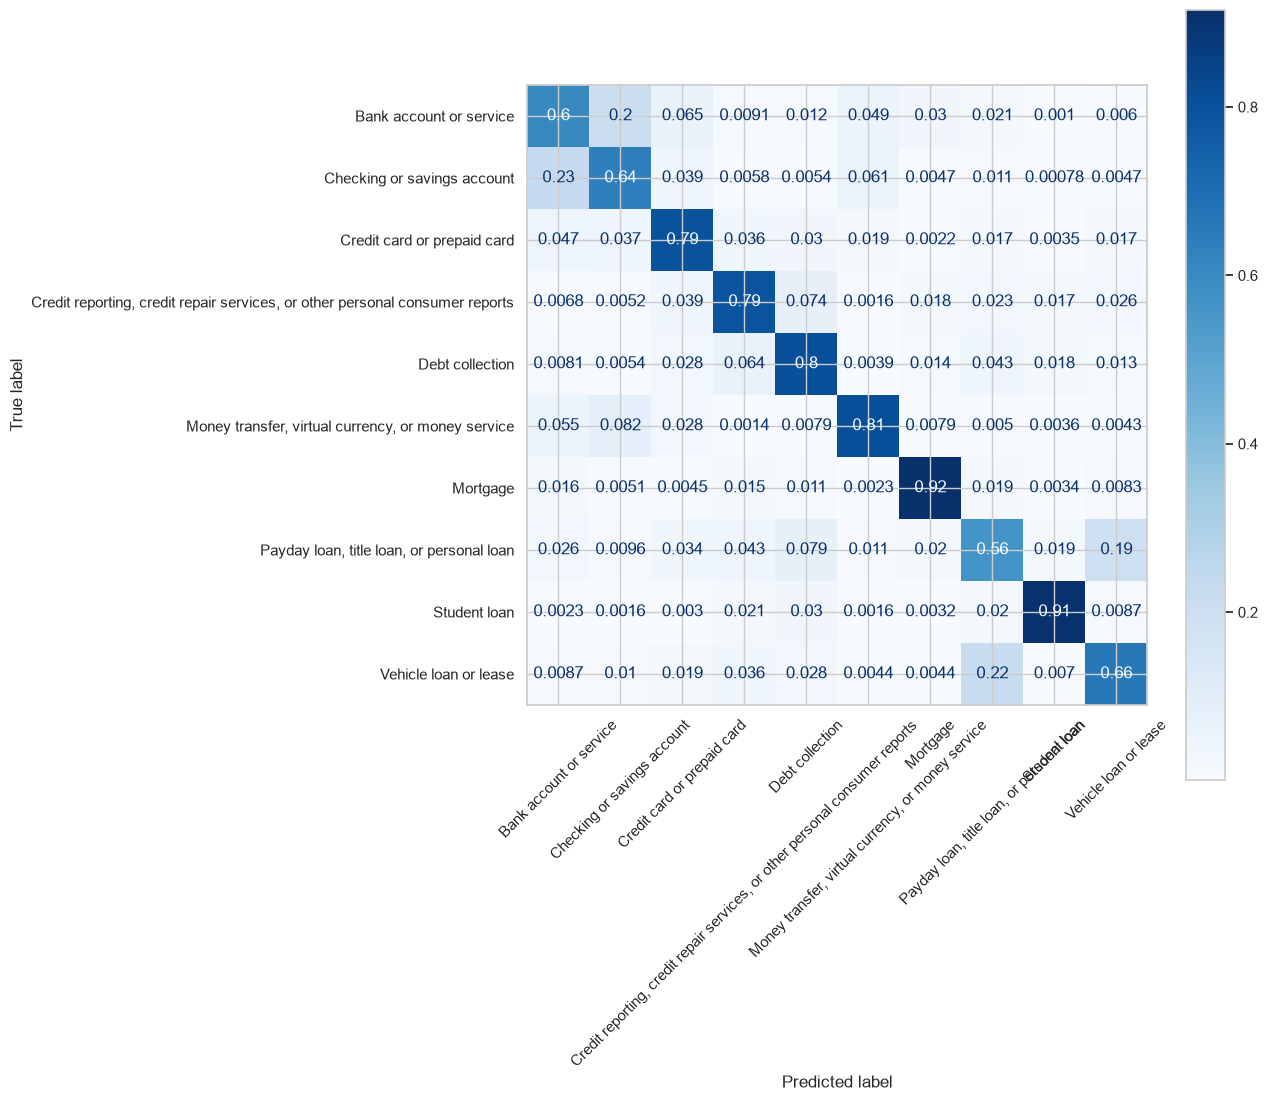

In [68]:
model_def = pd.read_pickle("../model/model.plk")
pred = model_def.predict(X_test)
pred_decod = lab_enc.inverse_transform(pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_decod, normalize="true", labels=lab_enc.classes_, ax=ax, xticks_rotation=45, cmap="Blues")
plt.show()
